In [1]:
import os
import gc
from pathlib import Path
from collections import Counter

import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests

import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from matplotlib_venn import venn2, venn3
from matplotlib.lines import Line2D

from upsetplot import from_contents, generate_counts, UpSet, plot, from_indicators
from pycirclize import Circos

import seaborn as sns

import anndata as ad
import scanpy as sc

%matplotlib inline

In [2]:
## FDR Calculation Function ##

def fdr_per_celltype(dge_df):
    """Add FDR-adjusted p-values and significance per cell type."""
    dge_df['p.adjusted'] = None
    dge_df['significant_fdr'] = False
    
    for celltype, group in dge_df.groupby('assay'):
        rejected, pvals_corrected, _, _ = multipletests(group['p.value'], method='fdr_bh')
        dge_df.loc[group.index, 'p.adjusted'] = pvals_corrected
        dge_df.loc[group.index, 'significant_fdr'] = rejected
    
    return dge_df

In [3]:
## Import AnnData Object ##

adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

## Toss Stressed Glia & Doublets ##

adata = adata[~(adata.obs['subclass_annotations'] == 'Stressed Glia') & ~adata.obs['pred_dbl']].copy()
gc.collect()

# Create Pseudobulk Col ##

adata.obs['Donor_Sample'] = adata.obs['Donor'].astype('str') + '_' + adata.obs['Sample Name'].astype('str')

In [4]:
## Known Genes In Deleted Regions ##

# https://bioinfo.uth.edu/SZGR/display/showGeneset #

CLASSIC_22q11 = ['TBX1', "COMT", "DGCR8", "TANGO2"]

ALL_22q11 = ["DERL3", "LRP5L", "SGSM1", "C22orf15", "LOC284890", "C22orf36", "PIWIL3", "GSTT2B",
                    "DDTL", "SMARCB1", "VPREB3", "SERPIND1", "MAPK1", "HIRA", "ZNF74", "CLTCL1",
                    "VPREB1", "GSTT2", "MMP11", "ZNF70", "CRYBB1", "CRKL", "BCR", "ADRBK2",
                    "MN1", "CHEK2", "APOL2", "C22orf28", "LOC652968", "FBXO7", "PVALB", "PPARA",
                    "TPST2", "PES1", "SEZ6L", "PITPNB", "TFIP11", "C22orf31", "ASPHD2", "KREMEN1",
                    "ZNRF3", "ASCC2", "HSCB", "CCDC117", "RHBDD3", "C22orf24", "TIMP3", "TBC1D10A",
                    "XBP1", "EWSR1", "LIF", "LIMK2", "DRG1", "NEFH", "NF2", "OSM",
                    "RFPL1", "SMTN", "TCN2", "NIPSNAP1", "THOC5", "MTMR3", "GAL3ST1", "SFI1",
                    "SF3A1", "RASL10A", "GAS2L1", "MORC2", "SEC14L2", "PATZ1", "PISD", "OSBP2",
                    "RNF185", "PIK3IP1", "EMID1", "SELM", "HORMAD2", "DUSP18", "CABP7", "RNF215",
                    "SEC14L3", "SEC14L4", "SLC35E4", "LOC550631", "SLC5A4", "C22orf30", "DGCR5",
                    "DGCR6L", "SUSD2", "SCZD4", "BID", "IL17RA", "BCL2L13", "TUBA8", "GAB4",
                    "CCT8L2", "XKR3", "TRMT2A", "RTDR1", "CECR2", "YPEL1", "LOC51233", "MED15",
                    "UPB1", "CECR1", "DGCR8", "GNB1L", "EIF4ENIF1", "SLC2A11", "THAP7", "OR11H1",
                    "C22orf13", "SLC25A18", "MYO18B", "CRYBB2", "CRYBB3", "CRYBA4", "PLA2G3",
                    "APOL4", "ACO2", "ARVCF", "GSC2", "PI4KA", "SEPT5", "PRODH", "RANBP1",
                    "SLC7A4", "SLC25A1", "TBX1", "CLDN5", "UBE2L3", "UFD1L", "CDC45L", "SNAP29",
                    "DGCR2", "TXNRD2", "USP18", "HIC2", "TSSK2", "SDF2L1", "PPIL2", "ZDHHC8",
                    "PEX26", "MICAL3", "MRPL40", "RTN4R", "C22orf29", "KLHL22", "SCARF2",
                    "C22orf25", "AIFM3", "CCDC116", "FLJ42953", "LOC440792", "COMT", "GP1BB",
                    "DGCR6", "LZTR1", "DGCR14", "GNAZ", "TOP3B", "RAB36", "PPM1F", "PRAME",
                    "DKFZP434P211", "LOC96610", "ZNF280A", "ZNF280B", "ADORA2A", "DDT",
                    "GGT1", "GSTT1", "IGLL1", "MIF", "SNRPD3", "SPECC1L", "CABIN1"]

CLASSIC_3q29 = ['DLG1', "PAK2", "TFRC", "C3orf34"]
BORDERLINE_3q29 = ['HES1', "CLDN1", "OPA1"]
ALL_3q29 = adata.var_names[adata.var_names.isin(CLASSIC_3q29 + BORDERLINE_3q29)].tolist()

CLASSIC_15q13 = ['HERC2', 'CHRFAM7A', 'CHP', 'FMN1']
BORDERLINE_15q13 = ['SCG5', 'SLC12A6', 'GREM1', 'MAP1A']
ALL_15q13 = adata.var_names[adata.var_names.isin(CLASSIC_15q13 + BORDERLINE_15q13)].tolist()

In [5]:
## Read in DEG Lists ##

CSV_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'

# by manuscript #
dge_fernando = pd.read_csv(Path(CSV_PATH) / 'dreamlet_fernando_dge_scz_results.csv')
dge_shin = pd.read_csv(Path(CSV_PATH) / 'dreamlet_shin_dge_scz_results.csv')
dge_purcell = pd.read_csv(Path(CSV_PATH) / 'dreamlet_purcell_dge_scz_results.csv')
dge_sebastian = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sebastian_dge_scz_results.csv')
dge_sawada = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sawada_dge_scz_results.csv')
dge_notaras = pd.read_csv(Path(CSV_PATH) / 'dreamlet_notaras_dge_scz_results.csv')
dge_rao = pd.read_csv(Path(CSV_PATH) / 'dreamlet_rao_dge_scz_results.csv')
dge_walsh_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_22q11_dge_scz_results.csv')
dge_walsh_15q13 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_15q13_dge_scz_results.csv')

# by disease #
dge_nrxn1 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_nrxn1_combined.csv')
dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_22q11_combined.csv')
dge_idiopathic = pd.read_csv(Path(CSV_PATH) / 'dreamlet_idiopathic_combined.csv')
dge_15q13 = dge_walsh_15q13
dge_3q29 = dge_purcell

In [6]:
# Make Assay ID #

# Put all dataframes in a dictionary
dge_dfs = {
    'dge_fernando': dge_fernando,
    'dge_shin': dge_shin,
    'dge_purcell': dge_purcell,
    'dge_sebastian': dge_sebastian,
    'dge_sawada': dge_sawada,
    'dge_notaras': dge_notaras,
    'dge_rao': dge_rao,
    'dge_walsh_22q11': dge_walsh_22q11,
    'dge_walsh_15q13': dge_walsh_15q13,
    'dge_nrxn1': dge_nrxn1,
    'dge_22q11': dge_22q11,
    'dge_idiopathic': dge_idiopathic,
    'dge_15q13': dge_15q13,
    'dge_3q29': dge_3q29
}

# Add assay_ID column to each
for name, df in dge_dfs.items():
    df['assay_ID'] = df['assay'].astype(str) + ' | ' + df['ID'].astype(str)

In [7]:
## Calculate FDR ##

dge_nrxn1 = fdr_per_celltype(dge_nrxn1)
dge_22q11 = fdr_per_celltype(dge_22q11)
dge_idiopathic = fdr_per_celltype(dge_idiopathic)

In [8]:
## Calculate Significant Gene Lists ##

# refine metaanalysis dataframes to significant hits across all studies 
significant_nrxn1_df = dge_nrxn1[(dge_nrxn1['p.adjusted'] < 0.05) & (dge_nrxn1['n.studies'] == 2)]
significant_22q11_df = dge_22q11[(dge_22q11['p.adjusted'] < 0.05) & (dge_22q11['n.studies'] == 3)]
significant_idiopathic_df = dge_idiopathic[(dge_idiopathic['p.adjusted'] < 0.05) & (dge_idiopathic['n.studies'] == 2)]

# make significnat gene lists
significant_nrxn1 = significant_nrxn1_df['ID'].tolist()
significant_22q11 = significant_22q11_df['ID'].tolist()
significant_idiopathic = significant_idiopathic_df['ID'].tolist()

# make sets from lists #
set_nrxn1 = set(significant_nrxn1)
set_22q11 = set(significant_22q11)
set_idiopathic = set(significant_idiopathic)

# make overlap lists ##
set_22q11_nrxn1 = set_22q11.intersection(set_nrxn1) 
set_22q11_idiopathic = set_22q11.intersection(set_idiopathic) 
set_nrnxn1_idiopathic = set_nrxn1.intersection(set_idiopathic) 

In [9]:
dge_15q13[(dge_15q13['adj.P.Val'] < 0.05)]

,assay,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,dataset,assay_ID


In [10]:
dge_3q29[(dge_3q29['adj.P.Val'] < 0.05)]

,assay,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,dataset,assay_ID
0,Radial Glia SOX2+VIM+FABP7+,UBXN7,-1.410543,5.178853,-13.097255,7.995727e-07,0.018796,6.357204,-13.097255,purcell,Radial Glia SOX2+VIM+FABP7+ | UBXN7
1,Radial Glia SOX2+VIM+FABP7+,PAK2,-1.201422,6.834729,-12.554585,1.118057e-06,0.018796,6.147169,-12.554585,purcell,Radial Glia SOX2+VIM+FABP7+ | PAK2
2,Radial Glia SOX2+VIM+FABP7+,NEAT1,-1.604934,8.615706,-12.475494,1.175337e-06,0.018796,6.154063,-12.475494,purcell,Radial Glia SOX2+VIM+FABP7+ | NEAT1
3,IPC EOMES+NEUROG2+PAX6+,CADM1,2.920552,5.867342,8.295579,1.482729e-06,0.018796,-2.307061,8.295579,purcell,IPC EOMES+NEUROG2+PAX6+ | CADM1
4,Radial Glia SOX2+VIM+FABP7+,SAT1,-1.201880,7.602492,-12.103017,1.493006e-06,0.018796,5.912923,-12.103017,purcell,Radial Glia SOX2+VIM+FABP7+ | SAT1
5,Radial Glia SOX2+VIM+FABP7+,TMEM159,-1.539923,3.495084,-11.795281,1.828545e-06,0.018796,5.401540,-11.795281,purcell,Radial Glia SOX2+VIM+FABP7+ | TMEM159
6,Radial Glia SOX2+VIM+FABP7+,BLOC1S6,-1.103334,6.054103,-11.776155,1.852020e-06,0.018796,5.664562,-11.776155,purcell,Radial Glia SOX2+VIM+FABP7+ | BLOC1S6
7,Radial Glia SOX2+VIM+FABP7+,RNF168,-1.560908,4.710141,-11.635163,2.035807e-06,0.018796,5.498788,-11.635163,purcell,Radial Glia SOX2+VIM+FABP7+ | RNF168
8,Radial Glia SOX2+VIM+FABP7+,BTG3,-0.975040,7.187944,-11.524175,2.194816e-06,0.018796,5.552051,-11.524175,purcell,Radial Glia SOX2+VIM+FABP7+ | BTG3
9,Radial Glia SOX2+VIM+FABP7+,LIPG,-1.263478,3.902009,-10.940261,3.296072e-06,0.025076,4.967994,-10.940261,purcell,Radial Glia SOX2+VIM+FABP7+ | LIPG


In [11]:
def add_directional_consistency(df):
    # Remove duplicate columns
    df = df.loc[:, ~df.columns.duplicated()].copy()
    
    # Identify logFC columns
    logfc_cols = [col for col in df.columns if col.startswith('logFC')]
    
    def check_direction(row):
        vals = row[logfc_cols].dropna()
        
        if len(vals) <= 1:
            return np.nan  # not enough data
        
        signs = np.sign(vals)
        signs = signs[signs != 0]  # optionally ignore zeros
        
        if len(signs) == 0:
            return np.nan
        
        return len(set(signs)) == 1  # True if all same sign
    
    # Add new column
    df['directionally_consistent'] = df.apply(check_direction, axis=1)
    
    return df

In [12]:
## Examining 22q11 Meta-Analysis ##

dge_shin_rao = dge_shin.merge(dge_rao, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_shin', '_rao'])

dge_walsh_22q11_renamed = dge_walsh_22q11.add_suffix('_walsh')
dge_walsh_22q11_renamed = dge_walsh_22q11_renamed.rename(columns={'assay_walsh': 'assay', 'ID_walsh': 'ID', 'assay_ID_walsh':'assay_ID'})

dge_shin_rao_walsh_22q11 = dge_shin_rao.merge(dge_walsh_22q11_renamed,
                                              left_on=['assay', 'ID', 'assay_ID'],
                                              right_on=['assay', 'ID', 'assay_ID'], how='inner')

significant_22q11_df_logfc = significant_22q11_df.merge(dge_shin_rao_walsh_22q11[['assay', 'ID', 'assay_ID', 
                                                                            'logFC_rao','logFC_shin', 'logFC_walsh']],
                                                  left_on=['assay', 'ID', 'assay_ID'], 
                                                  right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_22q11_df_logfc = add_directional_consistency(significant_22q11_df_logfc)

logfc_cols_22q11 = [i for i in significant_22q11_df_logfc.columns if 'logFC' in i]
significant_22q11_df_logfc['mean_logFC'] = significant_22q11_df_logfc[logfc_cols_22q11].mean(axis=1)

dc_significant_22q11_df_logfc = significant_22q11_df_logfc[significant_22q11_df_logfc['directionally_consistent'] == True]

significant_22q11_df_logfc['directionally_consistent'].mean()

0.5676126878130217

In [13]:
## Examining NRXN1 Meta-Analysis ##

dge_sebastian_fernando = dge_sebastian.merge(dge_fernando, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_sebastian', '_fernando'])

significant_nrxn1_df_logfc = significant_nrxn1_df.merge(dge_sebastian_fernando[['assay', 'ID', 'assay_ID', 
                                                                            'logFC_sebastian', 'logFC_fernando']],
                                                                            left_on=['assay', 'ID', 'assay_ID'], 
                                                                            right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_nrnx1_df_logfc = add_directional_consistency(significant_nrxn1_df_logfc)

logfc_cols_nrxn1 = [i for i in significant_nrnx1_df_logfc.columns if 'logFC' in i]
significant_nrnx1_df_logfc['mean_logFC'] = significant_nrnx1_df_logfc[logfc_cols_nrxn1].mean(axis=1)

dc_significant_nrxn1_df_logfc = significant_nrnx1_df_logfc[significant_nrnx1_df_logfc['directionally_consistent'] == True]

significant_nrnx1_df_logfc['directionally_consistent'].mean()

0.7546972860125261

In [14]:
## Examining Idiopathic Meta-Analysis ##

dge_sawada_notaras = dge_sawada.merge(dge_notaras, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_sawada', '_notaras'])

significant_idiopathic_df_logfc = significant_idiopathic_df.merge(dge_sawada_notaras[['assay', 'ID', 'assay_ID', 
                                                                                'logFC_sawada', 'logFC_notaras']],
                                                                                left_on=['assay', 'ID', 'assay_ID'], 
                                                                                right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_idiopathic_df_logfc = add_directional_consistency(significant_idiopathic_df_logfc)

logfc_cols_idiopathic = [i for i in significant_idiopathic_df_logfc.columns if 'logFC' in i]
significant_idiopathic_df_logfc['mean_logFC'] = significant_idiopathic_df_logfc[logfc_cols_idiopathic].mean(axis=1)

dc_significant_idiopathic_df_logfc = significant_idiopathic_df_logfc[significant_idiopathic_df_logfc['directionally_consistent'] == True]

significant_idiopathic_df_logfc['directionally_consistent'].mean()

0.744927536231884

In [15]:
dc_significant_22q11_df_logfc['assay'].value_counts()

assay
Radial Glia SOX2+VIM+FABP7+                    194
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+     50
Hindbrain Neurons NR2F2+PBX3+LHX1+              45
Proliferative Radial Glia SOX2+HES6+TOP2A+      39
Radial Glia SOX2+PAX6+FABP7+                     7
Mixed Neurons FGF12+GRIN2B+CAMK2B+               5
Name: count, dtype: int64

In [16]:
dc_significant_idiopathic_df_logfc['assay'].value_counts()

assay
Radial Glia SOX2+PAX6+FABP7+                  166
Proliferative Radial Glia SOX2+HES6+TOP2A+     83
Hindbrain Neurons NR2F2+PBX3+LHX1+              5
Radial Glia SOX2+VIM+FABP7+                     3
Name: count, dtype: int64

In [17]:
dc_significant_nrxn1_df_logfc['assay'].value_counts()

assay
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+    300
Astrocyte GFAP+AQP4+HOPX+                      134
IPC EOMES+NEUROG2+PAX6+                         88
Proliferative Radial Glia SOX2+HES6+TOP2A+      85
Mixed Neurons FGF12+GRIN2B+CAMK2B+              64
Radial Glia SOX2+PAX6+FABP7+                    31
Radial Glia SOX2+VIM+FABP7+                     18
Hindbrain Neurons NR2F2+PBX3+LHX1+               2
Mesenchymal-like cells VIM+VCAN+SPARC+           1
Name: count, dtype: int64

In [18]:
## Check Overlap Between Directionally Consistent MetaAnalyzed DataFrames ##

df_22q11_to_merge = dc_significant_22q11_df_logfc.copy()
df_22q11_to_merge.columns = [i+'_22q11' for i in df_22q11_to_merge.columns]

df_nrxn1_to_merge = dc_significant_nrxn1_df_logfc.copy()
df_nrxn1_to_merge.columns = [i+'_nrxn1' for i in df_nrxn1_to_merge.columns]

df_idiopathic_to_merge = dc_significant_idiopathic_df_logfc.copy()
df_idiopathic_to_merge.columns = [i+'_idiopathic' for i in dc_significant_idiopathic_df_logfc.columns]

df_22q11_nrxn1 = df_22q11_to_merge.merge(df_nrxn1_to_merge, 
                                         right_on=['ID_nrxn1', 'assay_nrxn1'], 
                                         left_on=['ID_22q11', 'assay_22q11'])

df_22q11_idiopathic = df_22q11_to_merge.merge(df_idiopathic_to_merge, 
                                              right_on=['ID_idiopathic', 'assay_idiopathic'], 
                                              left_on=['ID_22q11', 'assay_22q11'])

df_nrxn1_idiopathic = df_nrxn1_to_merge.merge(df_idiopathic_to_merge, 
                                              right_on=['ID_idiopathic', 'assay_idiopathic'], 
                                              left_on=['ID_nrxn1', 'assay_nrxn1'])

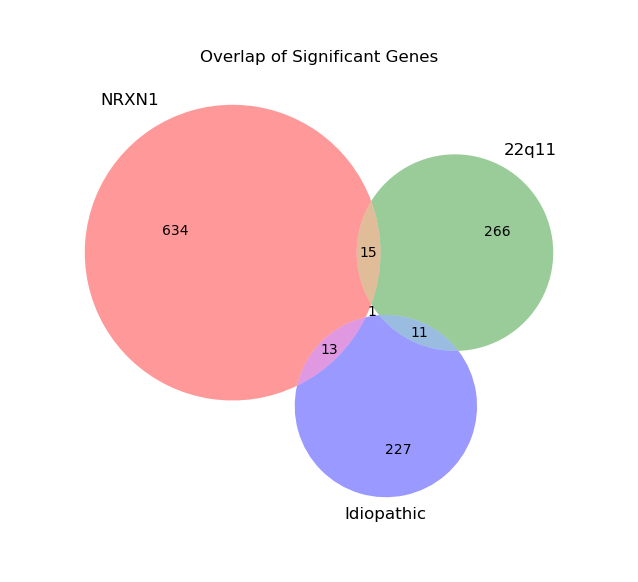

In [19]:
## Venn Diagram Of Overlap CellType Agonstic ##

# Convert your lists to sets
dge_nrxn1_set = set(dc_significant_nrxn1_df_logfc['ID'])
dge_22q11_set = set(dc_significant_22q11_df_logfc['ID'])
dge_idiopathic_set = set(dc_significant_idiopathic_df_logfc['ID'])

# --- Venn diagram for all three lists ---
plt.figure(figsize=(8, 6))
venn3([dge_nrxn1_set, dge_22q11_set, dge_idiopathic_set],
      set_labels=('NRXN1', '22q11', 'Idiopathic'))
plt.title("Overlap of Significant Genes")
plt.show()

In [20]:
dge_22q11_set.intersection(dge_idiopathic_set).intersection(dge_nrxn1_set)

{'WWC2'}

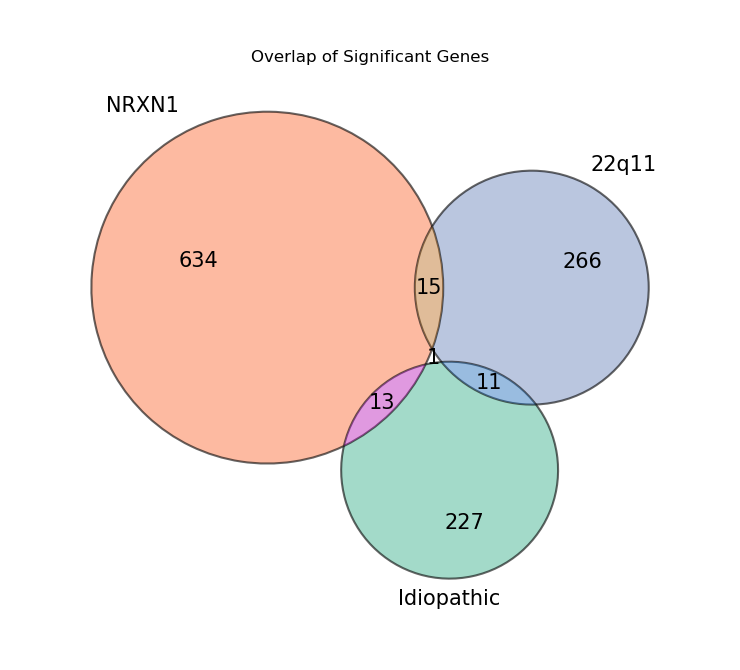

In [21]:
# Convert to sets
dge_nrxn1_set = set(dc_significant_nrxn1_df_logfc['ID'])
dge_22q11_set = set(dc_significant_22q11_df_logfc['ID'])
dge_idiopathic_set = set(dc_significant_idiopathic_df_logfc['ID'])

# Custom colors
COLORS = {
    "NRXN1": "#fc8d62ff",
    "22q11": "#8da0cbff",
    "Idiopathic": "#66c2a5ff"
}

plt.figure(figsize=(8, 6))

v = venn3(
    [dge_nrxn1_set, dge_22q11_set, dge_idiopathic_set],
    set_labels=('NRXN1', '22q11', 'Idiopathic')
)

# =====================================================
# MAIN SET COLORS + EDGES
# =====================================================

v.get_patch_by_id('100').set_color(COLORS["NRXN1"])
v.get_patch_by_id('100').set_alpha(0.6)
v.get_patch_by_id('100').set_edgecolor('black')
v.get_patch_by_id('100').set_linewidth(1.5)

v.get_patch_by_id('010').set_color(COLORS["22q11"])
v.get_patch_by_id('010').set_alpha(0.6)
v.get_patch_by_id('010').set_edgecolor('black')
v.get_patch_by_id('010').set_linewidth(1.5)

v.get_patch_by_id('001').set_color(COLORS["Idiopathic"])
v.get_patch_by_id('001').set_alpha(0.6)
v.get_patch_by_id('001').set_edgecolor('black')
v.get_patch_by_id('001').set_linewidth(1.5)

# =====================================================
# LABEL STYLING (optional polish)
# =====================================================

for text in v.set_labels:
    if text:
        text.set_fontsize(15)

for text in v.subset_labels:
    if text:
        text.set_fontsize(15)

plt.title("Overlap of Significant Genes")
plt.tight_layout()
plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_all_celltypes_venn.svg", bbox_inches='tight')
plt.show()

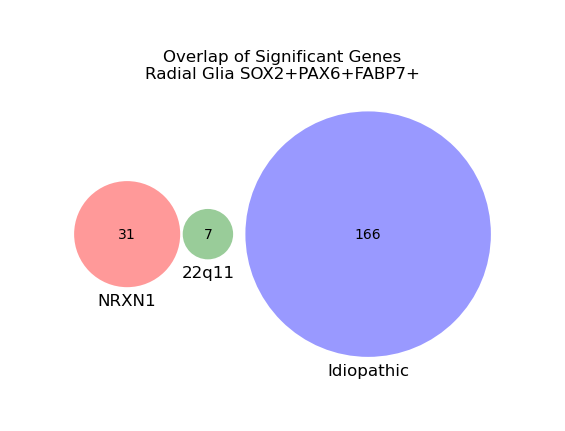

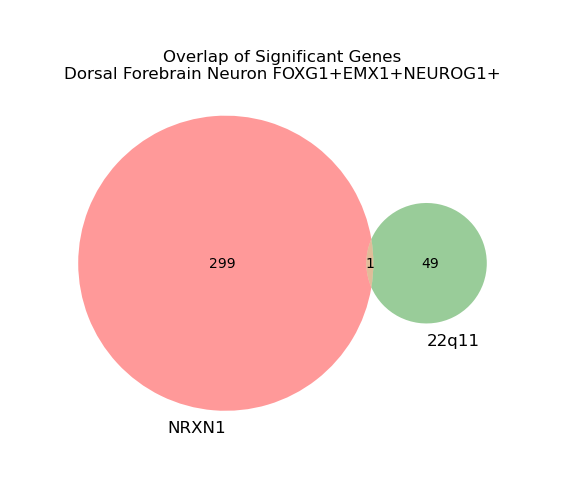

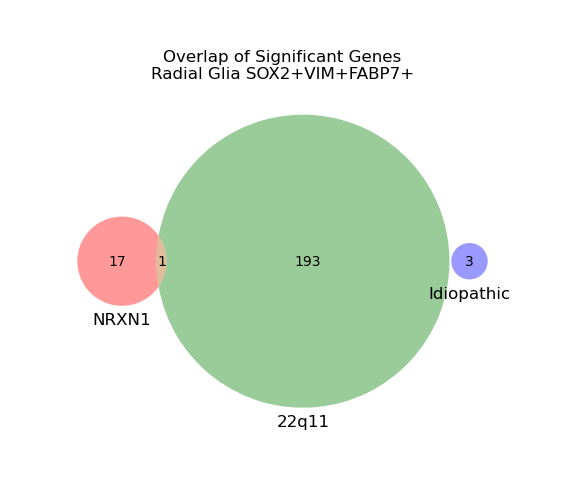

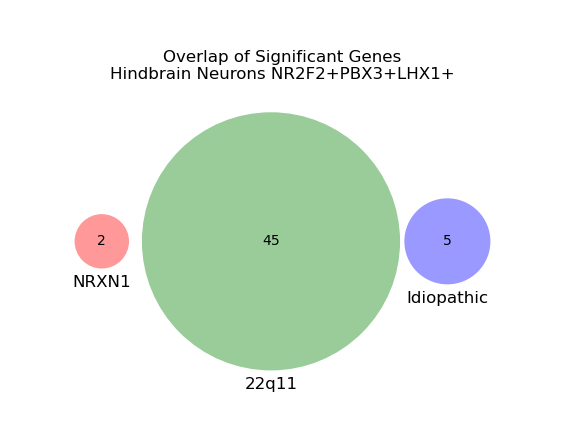

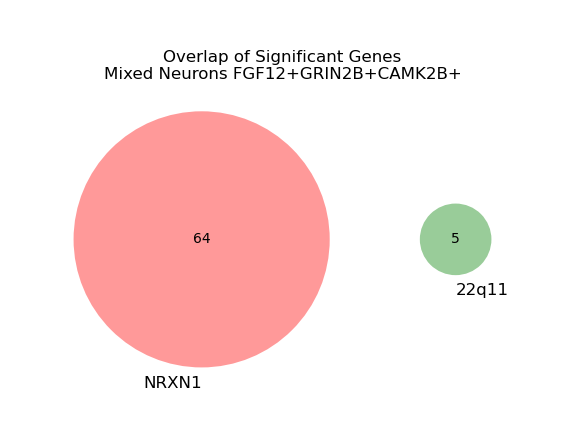

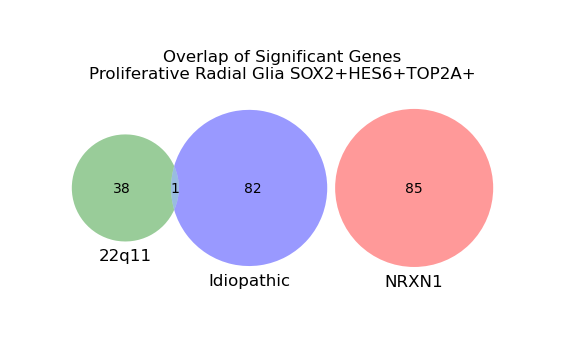

In [22]:
## Venn Diagram Of Overlap CellType Specific ##

# get all unique assays
assays = set(dc_significant_nrxn1_df_logfc['assay']) \
    | set(dc_significant_22q11_df_logfc['assay']) \
    | set(dc_significant_idiopathic_df_logfc['assay'])

for assay in assays:

    nrxn1_genes = set(dc_significant_nrxn1_df_logfc.loc[dc_significant_nrxn1_df_logfc['assay'] == assay, 'ID'])

    q22_genes = set(dc_significant_22q11_df_logfc.loc[dc_significant_22q11_df_logfc['assay'] == assay, 'ID'])

    idiopathic_genes = set(dc_significant_idiopathic_df_logfc.loc[dc_significant_idiopathic_df_logfc['assay'] == assay, 'ID'])

    sets = [('NRXN1', nrxn1_genes), ('22q11', q22_genes), ('Idiopathic', idiopathic_genes)]

    # keep only non-empty sets
    non_empty = [(name, s) for name, s in sets if len(s) > 0]

    # skip if fewer than 2 sets
    if len(non_empty) < 2:
        continue

    plt.figure(figsize=(6, 5))

    if len(non_empty) == 3:
        venn3([s for _, s in non_empty],
              set_labels=[n for n, _ in non_empty])

    elif len(non_empty) == 2:
        venn2([s for _, s in non_empty],
              set_labels=[n for n, _ in non_empty])

    plt.title(f"Overlap of Significant Genes\n{assay}")
    safe_assay = assay.replace(" ", "_").replace("+", "").replace("/", "_")
    
    plt.savefig(
        f"/home/deepak/datasets/scz_meta_analysis/panels/Figure_4_{safe_assay}_venn.svg", bbox_inches='tight')
    
    plt.show()

In [23]:
df_22q11_nrxn1[[i for i in df_22q11_nrxn1.columns if ('logFC' in i) or ('assay' in i)]]

## Theres only 4 instances across 2 celltypes when a gene is directionally shared across all manuscripts and significant ##
## In all of those intsances the signs are changed ##

,assay_22q11,assay_ID_22q11,logFC_rao_22q11,logFC_shin_22q11,logFC_walsh_22q11,mean_logFC_22q11,assay_nrxn1,assay_ID_nrxn1,logFC_sebastian_nrxn1,logFC_fernando_nrxn1,mean_logFC_nrxn1
0,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.931210,-0.482282,-0.962693,-0.792062,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.117488,0.517913,0.317700
1,Radial Glia SOX2+VIM+FABP7+,Radial Glia SOX2+VIM+FABP7+ | PIM1,-0.573554,-1.385680,-0.540774,-0.833336,Radial Glia SOX2+VIM+FABP7+,Radial Glia SOX2+VIM+FABP7+ | PIM1,0.214780,1.481326,0.848053


In [24]:
df_22q11_nrxn1[[i for i in df_22q11_nrxn1.columns if ('logFC' in i) or ('ID' in i)]]

,ID_22q11,assay_ID_22q11,logFC_rao_22q11,logFC_shin_22q11,logFC_walsh_22q11,mean_logFC_22q11,ID_nrxn1,assay_ID_nrxn1,logFC_sebastian_nrxn1,logFC_fernando_nrxn1,mean_logFC_nrxn1
0,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.931210,-0.482282,-0.962693,-0.792062,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.117488,0.517913,0.317700
1,PIM1,Radial Glia SOX2+VIM+FABP7+ | PIM1,-0.573554,-1.385680,-0.540774,-0.833336,PIM1,Radial Glia SOX2+VIM+FABP7+ | PIM1,0.214780,1.481326,0.848053


In [25]:
df_22q11_idiopathic

,ID_22q11,assay_22q11,estimate_22q11,std.error_22q11,statistic_22q11,p.value_22q11,n.studies_22q11,method_22q11,assay_ID_22q11,p.adjusted_22q11,...,p.value_idiopathic,n.studies_idiopathic,method_idiopathic,assay_ID_idiopathic,p.adjusted_idiopathic,significant_fdr_idiopathic,logFC_sawada_idiopathic,logFC_notaras_idiopathic,directionally_consistent_idiopathic,mean_logFC_idiopathic
0,PTPN13,Proliferative Radial Glia SOX2+HES6+TOP2A+,-0.322741,0.082883,-3.893935,0.000099,3,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | P...,0.015274,...,0.000514,2,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | P...,0.006092,True,-0.104303,-1.94918,True,-1.026742


In [26]:
df_nrxn1_idiopathic

,ID_nrxn1,assay_nrxn1,estimate_nrxn1,std.error_nrxn1,statistic_nrxn1,p.value_nrxn1,n.studies_nrxn1,method_nrxn1,assay_ID_nrxn1,p.adjusted_nrxn1,...,p.value_idiopathic,n.studies_idiopathic,method_idiopathic,assay_ID_idiopathic,p.adjusted_idiopathic,significant_fdr_idiopathic,logFC_sawada_idiopathic,logFC_notaras_idiopathic,directionally_consistent_idiopathic,mean_logFC_idiopathic


In [27]:
## Identify Genes Across Disease That May Not be Directionally Consistent Within a Disease, but Significant Within and Across Dx ##

df_22q11_non_dc_to_merge = significant_22q11_df_logfc.copy()
df_22q11_non_dc_to_merge.columns = [i+'_22q11' for i in df_22q11_non_dc_to_merge.columns]

df_nrxn1_non_dc_to_merge = significant_nrnx1_df_logfc.copy()
df_nrxn1_non_dc_to_merge.columns = [i+'_nrxn1' for i in df_nrxn1_non_dc_to_merge.columns]

df_idiopathic_non_dc_to_merge = significant_idiopathic_df_logfc.copy()
df_idiopathic_non_dc_to_merge.columns = [i+'_idiopathic' for i in df_idiopathic_non_dc_to_merge.columns]

df_22q11_nrxn1_non_dc = df_22q11_non_dc_to_merge.merge(df_nrxn1_non_dc_to_merge, 
                                         right_on=['ID_nrxn1', 'assay_nrxn1'], 
                                         left_on=['ID_22q11', 'assay_22q11'])

df_22q11_idiopathic_non_dc = df_22q11_non_dc_to_merge.merge(df_idiopathic_non_dc_to_merge, 
                                              right_on=['ID_idiopathic', 'assay_idiopathic'], 
                                              left_on=['ID_22q11', 'assay_22q11'])

df_nrxn1_idiopathic_non_dc = df_nrxn1_non_dc_to_merge.merge(df_idiopathic_non_dc_to_merge, 
                                              right_on=['ID_idiopathic', 'assay_idiopathic'], 
                                              left_on=['ID_nrxn1', 'assay_nrxn1'])

In [28]:
df_22q11_nrxn1_non_dc[[i for i in df_22q11_nrxn1_non_dc.columns if ('logFC' in i) or ('ID' in i)]]

## if you lax the constraints to take things thta dont have full directional consistency, you can get a few extra hits ##
## one of which has NRXN1 22q11.2 deletion mixup ## Nothing Shared with Idiopathic ##

,ID_22q11,assay_ID_22q11,logFC_rao_22q11,logFC_shin_22q11,logFC_walsh_22q11,mean_logFC_22q11,ID_nrxn1,assay_ID_nrxn1,logFC_sebastian_nrxn1,logFC_fernando_nrxn1,mean_logFC_nrxn1
0,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.931210,-0.482282,-0.962693,-0.792062,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.117488,0.517913,0.317700
1,GOLGA8B,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.771310,-0.019227,1.023847,0.591977,GOLGA8B,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.251183,-1.051003,-0.399910
2,PDGFD,Radial Glia SOX2+VIM+FABP7+ | PDGFD,0.810287,0.751816,0.082459,0.548187,PDGFD,Radial Glia SOX2+VIM+FABP7+ | PDGFD,0.163255,-1.800072,-0.818409
3,PIM1,Radial Glia SOX2+VIM+FABP7+ | PIM1,-0.573554,-1.385680,-0.540774,-0.833336,PIM1,Radial Glia SOX2+VIM+FABP7+ | PIM1,0.214780,1.481326,0.848053


In [29]:
df_22q11_idiopathic_non_dc

,ID_22q11,assay_22q11,estimate_22q11,std.error_22q11,statistic_22q11,p.value_22q11,n.studies_22q11,method_22q11,assay_ID_22q11,p.adjusted_22q11,...,p.value_idiopathic,n.studies_idiopathic,method_idiopathic,assay_ID_idiopathic,p.adjusted_idiopathic,significant_fdr_idiopathic,logFC_sawada_idiopathic,logFC_notaras_idiopathic,directionally_consistent_idiopathic,mean_logFC_idiopathic
0,PTPN13,Proliferative Radial Glia SOX2+HES6+TOP2A+,-0.322741,0.082883,-3.893935,0.000099,3,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | P...,0.015274,...,0.000514,2,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | P...,0.006092,True,-0.104303,-1.94918,True,-1.026742


In [30]:
df_nrxn1_idiopathic_non_dc

,ID_nrxn1,assay_nrxn1,estimate_nrxn1,std.error_nrxn1,statistic_nrxn1,p.value_nrxn1,n.studies_nrxn1,method_nrxn1,assay_ID_nrxn1,p.adjusted_nrxn1,...,p.value_idiopathic,n.studies_idiopathic,method_idiopathic,assay_ID_idiopathic,p.adjusted_idiopathic,significant_fdr_idiopathic,logFC_sawada_idiopathic,logFC_notaras_idiopathic,directionally_consistent_idiopathic,mean_logFC_idiopathic


In [31]:
## What if it was enough that a single gene was showing up in multiple different disease in the same direction ideally ##

sig_22q11_idiopathic_set = set(dc_significant_22q11_df_logfc['ID']).intersection(dc_significant_idiopathic_df_logfc['ID'])

sig_22q11_nrxn1_set = set(dc_significant_22q11_df_logfc['ID']).intersection(dc_significant_nrxn1_df_logfc['ID'])

sig_idiopathic_nrxn1_set = set(dc_significant_idiopathic_df_logfc['ID']).intersection(dc_significant_nrxn1_df_logfc['ID'])

In [32]:
dc_significant_all = pd.concat([dc_significant_idiopathic_df_logfc.assign(group='Idiopathic Schizophrenia'),
                                dc_significant_nrxn1_df_logfc.assign(group='NRXN1del'), 
                                dc_significant_22q11_df_logfc.assign(group='22q11.2del')], axis=0)

In [33]:
dc_significant_all[dc_significant_all['ID'].isin(sig_22q11_idiopathic_set)]

,ID,assay,estimate,std.error,statistic,p.value,n.studies,method,assay_ID,p.adjusted,...,logFC_sawada,logFC_notaras,directionally_consistent,mean_logFC,group,logFC_sebastian,logFC_fernando,logFC_rao,logFC_shin,logFC_walsh
13,ARFGAP1,Radial Glia SOX2+PAX6+FABP7+,1.138057,0.253955,4.481326,7.418086e-06,2,FE,Radial Glia SOX2+PAX6+FABP7+ | ARFGAP1,0.000175,...,0.236067,1.538420,True,0.887243,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
15,ARL5B,Radial Glia SOX2+PAX6+FABP7+,0.593515,0.209138,2.837905,4.541065e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | ARL5B,0.026245,...,0.444488,0.712637,True,0.578563,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
68,CNOT1,Radial Glia SOX2+PAX6+FABP7+,0.660485,0.195281,3.382234,7.189898e-04,2,FE,Radial Glia SOX2+PAX6+FABP7+ | CNOT1,0.006441,...,0.254040,0.898589,True,0.576314,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
86,CWC22,Radial Glia SOX2+PAX6+FABP7+,-0.753128,0.223357,-3.371860,7.466239e-04,2,FE,Radial Glia SOX2+PAX6+FABP7+ | CWC22,0.006642,...,-0.015964,-1.163962,True,-0.589963,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
116,FGFR3,Radial Glia SOX2+PAX6+FABP7+,0.949626,0.301747,3.147093,1.649026e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | FGFR3,0.012185,...,1.289521,0.809575,True,1.049548,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
152,IST1,Radial Glia SOX2+PAX6+FABP7+,0.612144,0.202261,3.026504,2.473994e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | IST1,0.016366,...,0.369468,0.750609,True,0.560039,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
180,NAE1,Radial Glia SOX2+PAX6+FABP7+,-0.588743,0.201519,-2.921522,3.483255e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | NAE1,0.021367,...,-0.194280,-0.797137,True,-0.495708,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
207,PCGF5,Radial Glia SOX2+PAX6+FABP7+,-0.671878,0.219370,-3.062763,2.193037e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | PCGF5,0.014942,...,-0.738346,-0.608290,True,-0.673318,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
230,PTPN13,Proliferative Radial Glia SOX2+HES6+TOP2A+,-0.821684,0.236569,-3.473342,5.140207e-04,2,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | P...,0.006092,...,-0.104303,-1.949180,True,-1.026742,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
268,SLC25A1,Radial Glia SOX2+PAX6+FABP7+,0.526404,0.193213,2.724475,6.440377e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | SLC25A1,0.034063,...,0.115050,0.743852,True,0.429451,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN


In [34]:
dc_significant_all[dc_significant_all['ID'].isin(sig_22q11_nrxn1_set)]

,ID,assay,estimate,std.error,statistic,p.value,n.studies,method,assay_ID,p.adjusted,...,logFC_sawada,logFC_notaras,directionally_consistent,mean_logFC,group,logFC_sebastian,logFC_fernando,logFC_rao,logFC_shin,logFC_walsh
334,WWC2,Radial Glia SOX2+PAX6+FABP7+,0.716472,0.222280,3.223286,1.267291e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | WWC2,0.009917,...,0.441549,0.888741,True,0.665145,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
34,ALDH9A1,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,0.403603,0.102877,3.923170,8.739134e-05,2,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.005844,...,NaN,NaN,True,0.393876,NRXN1del,0.229658,0.558094,NaN,NaN,NaN
150,CITED2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,0.571930,0.140862,4.060220,4.902647e-05,2,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.003828,...,NaN,NaN,True,0.416502,NRXN1del,0.111346,0.721659,NaN,NaN,NaN
151,CITED2,Mixed Neurons FGF12+GRIN2B+CAMK2B+,0.625684,0.128969,4.851446,1.225649e-06,2,FE,Mixed Neurons FGF12+GRIN2B+CAMK2B+ | CITED2,0.000732,...,NaN,NaN,True,0.415624,NRXN1del,0.100658,0.730591,NaN,NaN,NaN
277,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,0.381210,0.100870,3.779235,1.573109e-04,2,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.008815,...,NaN,NaN,True,0.317700,NRXN1del,0.117488,0.517913,NaN,NaN,NaN
278,ETNK1,Astrocyte GFAP+AQP4+HOPX+,1.079115,0.331134,3.258847,1.118659e-03,2,FE,Astrocyte GFAP+AQP4+HOPX+ | ETNK1,0.019474,...,NaN,NaN,True,0.744709,NRXN1del,0.146993,1.342426,NaN,NaN,NaN
389,IER5,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,0.540688,0.136857,3.950752,7.790596e-05,2,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.005328,...,NaN,NaN,True,0.460562,NRXN1del,0.107279,0.813845,NaN,NaN,NaN
399,IRS1,Mixed Neurons FGF12+GRIN2B+CAMK2B+,0.541232,0.136237,3.972731,7.105335e-05,2,FE,Mixed Neurons FGF12+GRIN2B+CAMK2B+ | IRS1,0.014299,...,NaN,NaN,True,0.346463,NRXN1del,0.069387,0.623538,NaN,NaN,NaN
411,KHDRBS3,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,0.667535,0.167700,3.980543,6.875808e-05,2,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.004848,...,NaN,NaN,True,0.704091,NRXN1del,0.511655,0.896527,NaN,NaN,NaN
445,LRIF1,Proliferative Radial Glia SOX2+HES6+TOP2A+,-0.464016,0.119987,-3.867220,1.100832e-04,2,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | L...,0.019336,...,NaN,NaN,True,-0.328131,NRXN1del,-0.084454,-0.571807,NaN,NaN,NaN


In [35]:
dc_significant_all[dc_significant_all['ID'].isin(sig_idiopathic_nrxn1_set)]

,ID,assay,estimate,std.error,statistic,p.value,n.studies,method,assay_ID,p.adjusted,...,logFC_sawada,logFC_notaras,directionally_consistent,mean_logFC,group,logFC_sebastian,logFC_fernando,logFC_rao,logFC_shin,logFC_walsh
2,ACAT2,Proliferative Radial Glia SOX2+HES6+TOP2A+,-0.769977,0.239647,-3.212958,1.313754e-03,2,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | A...,0.012434,...,-0.531587,-1.100589,True,-0.816088,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
124,GMNN,Radial Glia SOX2+PAX6+FABP7+,-0.830328,0.205176,-4.046906,5.189914e-05,2,FE,Radial Glia SOX2+PAX6+FABP7+ | GMNN,0.000812,...,-0.233035,-1.160199,True,-0.696617,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
132,GTF2H2,Radial Glia SOX2+PAX6+FABP7+,-0.728649,0.202898,-3.591212,3.291439e-04,2,FE,Radial Glia SOX2+PAX6+FABP7+ | GTF2H2,0.00349,...,-0.004402,-1.463980,True,-0.734191,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
134,H2AZ1,Radial Glia SOX2+PAX6+FABP7+,-0.523346,0.196016,-2.669914,7.587061e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | H2AZ1,0.038336,...,-0.515356,-0.528945,True,-0.522150,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
143,IER3IP1,Radial Glia SOX2+PAX6+FABP7+,-0.518882,0.187641,-2.765286,5.687293e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | IER3IP1,0.031074,...,-0.061245,-0.828717,True,-0.444981,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
158,KLF13,Proliferative Radial Glia SOX2+HES6+TOP2A+,-0.753806,0.261557,-2.881992,3.951692e-03,2,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | K...,0.028208,...,-0.470349,-1.071876,True,-0.771112,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
173,MID1IP1,Radial Glia SOX2+PAX6+FABP7+,0.655463,0.191980,3.414226,6.396339e-04,2,FE,Radial Glia SOX2+PAX6+FABP7+ | MID1IP1,0.005852,...,0.296491,0.887862,True,0.592176,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
175,MPP5,Proliferative Radial Glia SOX2+HES6+TOP2A+,-0.896524,0.255693,-3.506252,4.544641e-04,2,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | MPP5,0.005541,...,-0.554074,-1.111785,True,-0.832929,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
243,RIOK3,Radial Glia SOX2+PAX6+FABP7+,0.603009,0.218876,2.755021,5.868840e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | RIOK3,0.031844,...,0.301603,0.712202,True,0.506902,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
281,SNHG8,Proliferative Radial Glia SOX2+HES6+TOP2A+,1.008659,0.322687,3.125808,1.773170e-03,2,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | S...,0.015761,...,0.033287,3.440751,True,1.737019,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN


In [36]:
def plot_count_strip(values, orientation="horizontal", cmap="Reds", figsize=None, dataset_label='',
                     annotate=True, vmin=None, vmax=None, cbar=True, save=False):
    
    values = np.array(values)
    
    if orientation == "horizontal":
        data = values.reshape(1, -1)
        if figsize is None:
            figsize = (len(values)*1.24191295198, 1)
        xticklabels = False
        yticklabels = False
        
    elif orientation == "vertical":
        data = values.reshape(-1, 1)
        if figsize is None:
            figsize = (1.24191295198, len(values))
        xticklabels = False
        yticklabels = False
        
    else:
        raise ValueError("orientation must be 'horizontal' or 'vertical'")
    
    plt.figure(figsize=figsize)
    
    sns.heatmap(data, cmap=cmap, cbar=cbar, annot=annotate, fmt=".0f", xticklabels=xticklabels, 
                yticklabels=yticklabels, vmin=vmin, vmax=vmax)
    
    #plt.tight_layout()
    
    if save:
        plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_{dataset_label}_{orientation}_upset_heatmap.svg")
    
    plt.show()

In [37]:
def plot_assay_upset(df, set_col='group', gene_col='ID', significance_col='significant_fdr', 
                     min_size=1, dataset_label="", top_graph=True, side_graph=True, title=True, 
                     save=False):

    # filter significant genes
    if significance_col in df.columns:
        df = df[df[significance_col] == True]
    
    assay_sets = {val: set(group[gene_col].dropna().unique())
        for val, group in df.groupby(set_col)}
    
    # remove small sets
    assay_sets = {k: v for k, v in assay_sets.items() if len(v) >= min_size}
    
    # safety check
    if len(assay_sets) < 2:
        print(f"Not enough groups to plot: {list(assay_sets.keys())}")
        return
    
    # convert
    upset_data = from_contents(assay_sets)
    
    plt.figure(figsize=(10, 6))

    if top_graph and side_graph:
        upset = UpSet(upset_data, show_counts=True, sort_by='degree')
    elif top_graph and not side_graph:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, totals_plot_elements=0)
    elif side_graph and not top_graph:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, intersection_plot_elements=())
    else:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, intersection_plot_elements=(), totals_plot_elements=0)
    
    upset.plot()

    if title:
        plt.suptitle(f"{dataset_label} Shared DGEs")
        
    if save:
        plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_{dataset_label}_upset_.svg")
    
    plt.show()

In [38]:
dc_significant_all['group'].value_counts()

group
NRXN1del                    723
22q11.2del                  340
Idiopathic Schizophrenia    257
Name: count, dtype: int64

In [39]:
dc_significant_all['assay'].value_counts()

assay
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+    350
Radial Glia SOX2+VIM+FABP7+                    215
Proliferative Radial Glia SOX2+HES6+TOP2A+     207
Radial Glia SOX2+PAX6+FABP7+                   204
Astrocyte GFAP+AQP4+HOPX+                      134
IPC EOMES+NEUROG2+PAX6+                         88
Mixed Neurons FGF12+GRIN2B+CAMK2B+              69
Hindbrain Neurons NR2F2+PBX3+LHX1+              52
Mesenchymal-like cells VIM+VCAN+SPARC+           1
Name: count, dtype: int64

In [40]:
dc_significant_all_rg_pax6 = dc_significant_all[dc_significant_all['assay'] == 'Radial Glia SOX2+PAX6+FABP7+']
dc_significant_all_prg = dc_significant_all[dc_significant_all['assay'] == 'Proliferative Radial Glia SOX2+HES6+TOP2A+']
dc_significant_all_rg_vim = dc_significant_all[dc_significant_all['assay'] == 'Radial Glia SOX2+VIM+FABP7+']
dc_significant_all_ipc = dc_significant_all[dc_significant_all['assay'] == 'IPC EOMES+NEUROG2+PAX6+']
dc_significant_all_dorsal = dc_significant_all[dc_significant_all['assay'] == 'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+']
dc_significant_all_mixed = dc_significant_all[dc_significant_all['assay'] == 'Mixed Neurons FGF12+GRIN2B+CAMK2B+']
dc_significant_all_hindbrain = dc_significant_all[dc_significant_all['assay'] == 'Hindbrain Neurons NR2F2+PBX3+LHX1+']
dc_significant_all_mc = dc_significant_all[dc_significant_all['assay'] == 'Mesenchymal-like cells VIM+VCAN+SPARC+']
dc_significant_all_astro = dc_significant_all[dc_significant_all['assay'] == 'Astrocyte GFAP+AQP4+HOPX+']

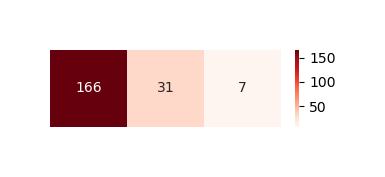

In [41]:
plot_count_strip([166, 31, 7], dataset_label="Radial Glia SOX2+PAX6+FABP7+", save=True)

<Figure size 1000x600 with 0 Axes>

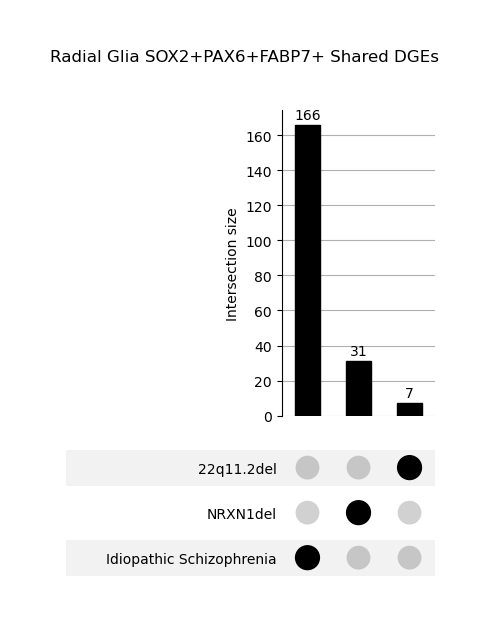

In [42]:
plot_assay_upset(dc_significant_all_rg_pax6,  dataset_label="Radial Glia SOX2+PAX6+FABP7+", 
                 set_col='group', top_graph=True, side_graph=False, save=True)

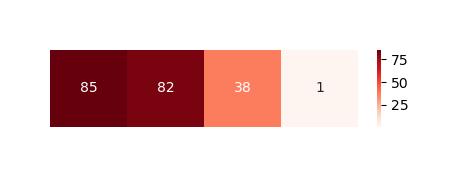

In [43]:
plot_count_strip([85, 82, 38, 1], dataset_label="Proliferative Radial Glia SOX2+HES6+TOP2A+", save=True)

<Figure size 1000x600 with 0 Axes>

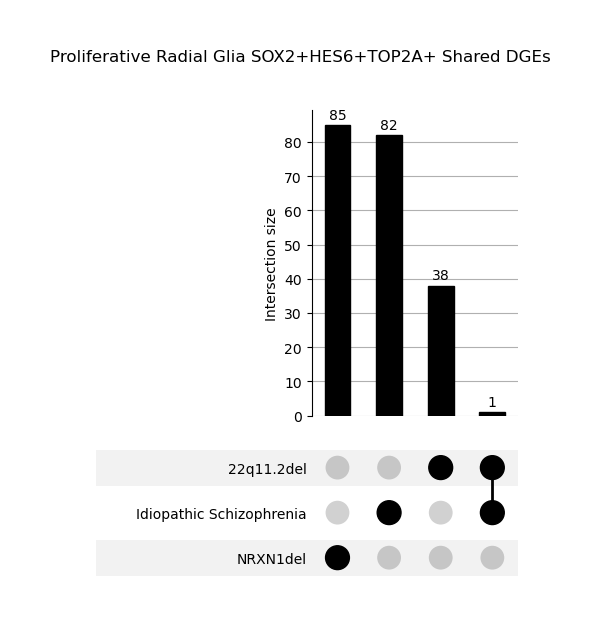

In [44]:
plot_assay_upset(dc_significant_all_prg, dataset_label="Proliferative Radial Glia SOX2+HES6+TOP2A+", 
                 set_col='group', top_graph=True, side_graph=False, save=True)

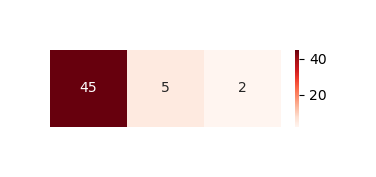

In [45]:
plot_count_strip([45, 5, 2], dataset_label="Hindbrain Neurons NR2F2+PBX3+LHX1+", save=True)

<Figure size 1000x600 with 0 Axes>

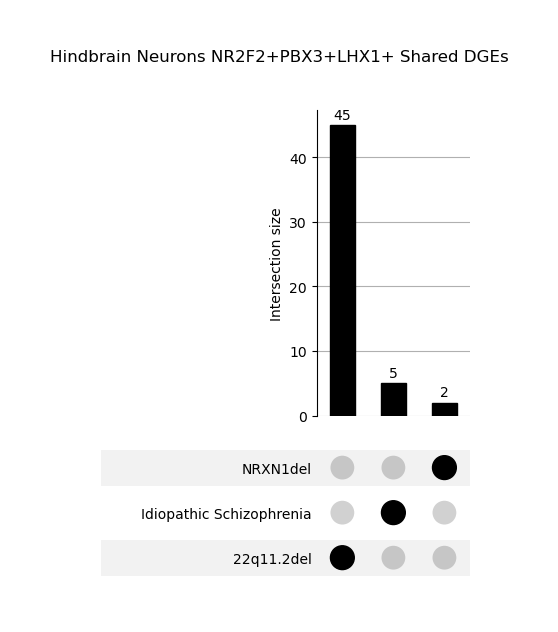

In [46]:
plot_assay_upset(dc_significant_all_hindbrain, dataset_label="Hindbrain Neurons NR2F2+PBX3+LHX1+",
                 set_col='group', top_graph=True, side_graph=False, save=True)

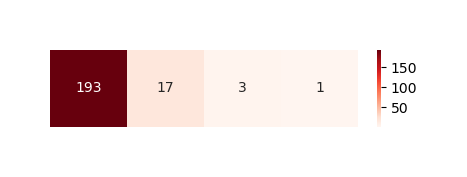

In [47]:
plot_count_strip([193, 17, 3, 1], dataset_label="Radial Glia SOX2+VIM+FABP7+", save=True)

<Figure size 1000x600 with 0 Axes>

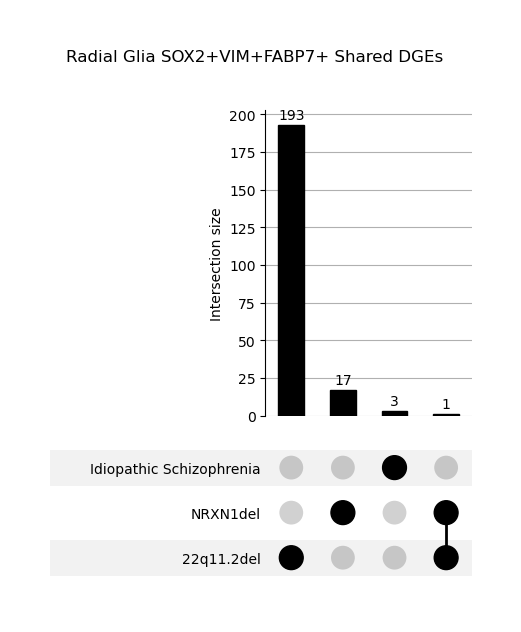

In [48]:
plot_assay_upset(dc_significant_all_rg_vim, dataset_label="Radial Glia SOX2+VIM+FABP7+", set_col='group',
                 top_graph=True, side_graph=False, save=True)

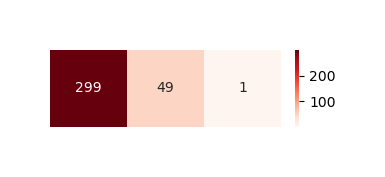

In [49]:
plot_count_strip([299, 49, 1], dataset_label="Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+", save=True)

<Figure size 1000x600 with 0 Axes>

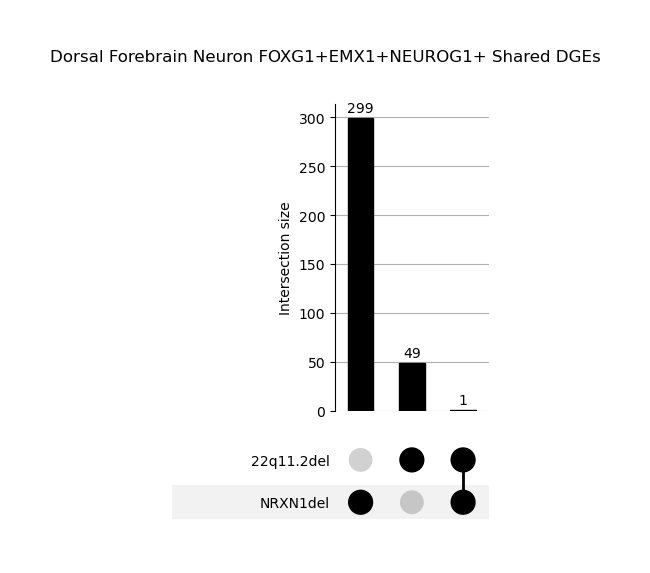

In [50]:
plot_assay_upset(dc_significant_all_dorsal, dataset_label="Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+",
                 set_col='group', top_graph=True, side_graph=False, save=True)

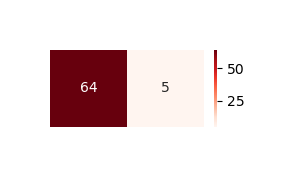

In [51]:
plot_count_strip([64, 5], dataset_label="Mixed Neurons FGF12+GRIN2B+CAMK2B+", save=True)

<Figure size 1000x600 with 0 Axes>

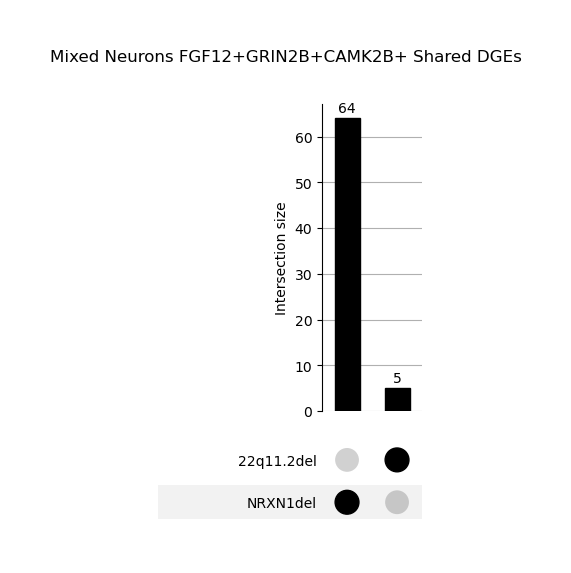

In [52]:
plot_assay_upset(dc_significant_all_mixed, dataset_label="Mixed Neurons FGF12+GRIN2B+CAMK2B+",  
                 set_col='group', top_graph=True, side_graph=False, save=True)

In [53]:
plot_assay_upset(dc_significant_all_astro, dataset_label="Astrocyte",  
                 set_col='group', top_graph=True, side_graph=False, save=True)

Not enough groups to plot: ['NRXN1del']


In [54]:
plot_assay_upset(dc_significant_all_ipc, dataset_label="IPC",  
                 set_col='group', top_graph=True, side_graph=False, save=True)

Not enough groups to plot: ['NRXN1del']


In [55]:
## Find Duplicates in Dorsal DGE ##

dc_significant_all_dorsal[dc_significant_all_dorsal['ID'].duplicated(keep=False)]

,ID,assay,estimate,std.error,statistic,p.value,n.studies,method,assay_ID,p.adjusted,...,logFC_sawada,logFC_notaras,directionally_consistent,mean_logFC,group,logFC_sebastian,logFC_fernando,logFC_rao,logFC_shin,logFC_walsh
277,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,0.381210,0.100870,3.779235,1.573109e-04,2,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.008815,...,NaN,NaN,True,0.317700,NRXN1del,0.117488,0.517913,NaN,NaN,NaN
159,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,-0.861508,0.117751,-7.316366,2.547755e-13,3,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.0,...,NaN,NaN,True,-0.792062,22q11.2del,NaN,NaN,-0.93121,-0.482282,-0.962693


In [56]:
## Find Duplicates in RG VIM+ DGE ##

dc_significant_all_rg_vim[dc_significant_all_rg_vim['ID'].duplicated(keep=False)]

,ID,assay,estimate,std.error,statistic,p.value,n.studies,method,assay_ID,p.adjusted,...,logFC_sawada,logFC_notaras,directionally_consistent,mean_logFC,group,logFC_sebastian,logFC_fernando,logFC_rao,logFC_shin,logFC_walsh
610,PIM1,Radial Glia SOX2+VIM+FABP7+,1.006274,0.209890,4.794298,1.632453e-06,2,FE,Radial Glia SOX2+VIM+FABP7+ | PIM1,0.000937,...,NaN,NaN,True,0.848053,NRXN1del,0.21478,1.481326,NaN,NaN,NaN
372,PIM1,Radial Glia SOX2+VIM+FABP7+,-1.011566,0.177351,-5.703763,1.171907e-08,3,FE,Radial Glia SOX2+VIM+FABP7+ | PIM1,0.000005,...,NaN,NaN,True,-0.833336,22q11.2del,NaN,NaN,-0.573554,-1.38568,-0.540774


In [57]:
## Find Duplicates in proliferative RGs ##

dc_significant_all_prg[dc_significant_all_prg['ID'].duplicated(keep=False)]

,ID,assay,estimate,std.error,statistic,p.value,n.studies,method,assay_ID,p.adjusted,...,logFC_sawada,logFC_notaras,directionally_consistent,mean_logFC,group,logFC_sebastian,logFC_fernando,logFC_rao,logFC_shin,logFC_walsh
230,PTPN13,Proliferative Radial Glia SOX2+HES6+TOP2A+,-0.821684,0.236569,-3.473342,0.000514,2,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | P...,0.006092,...,-0.104303,-1.94918,True,-1.026742,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
398,PTPN13,Proliferative Radial Glia SOX2+HES6+TOP2A+,-0.322741,0.082883,-3.893935,0.000099,3,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | P...,0.015274,...,NaN,NaN,True,-0.420705,22q11.2del,NaN,NaN,-0.260769,-0.232399,-0.768948


In [58]:
dc_significant_all_dorsal[dc_significant_all_dorsal['ID'].duplicated(keep=False)]

,ID,assay,estimate,std.error,statistic,p.value,n.studies,method,assay_ID,p.adjusted,...,logFC_sawada,logFC_notaras,directionally_consistent,mean_logFC,group,logFC_sebastian,logFC_fernando,logFC_rao,logFC_shin,logFC_walsh
277,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,0.381210,0.100870,3.779235,1.573109e-04,2,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.008815,...,NaN,NaN,True,0.317700,NRXN1del,0.117488,0.517913,NaN,NaN,NaN
159,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,-0.861508,0.117751,-7.316366,2.547755e-13,3,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.0,...,NaN,NaN,True,-0.792062,22q11.2del,NaN,NaN,-0.93121,-0.482282,-0.962693


In [59]:
forest_dfs = pd.concat([dc_significant_all_rg_vim[dc_significant_all_rg_vim['ID'].duplicated(keep=False)],
              dc_significant_all_prg[dc_significant_all_prg['ID'].duplicated(keep=False)],
              dc_significant_all_dorsal[dc_significant_all_dorsal['ID'].duplicated(keep=False)]], axis=0)

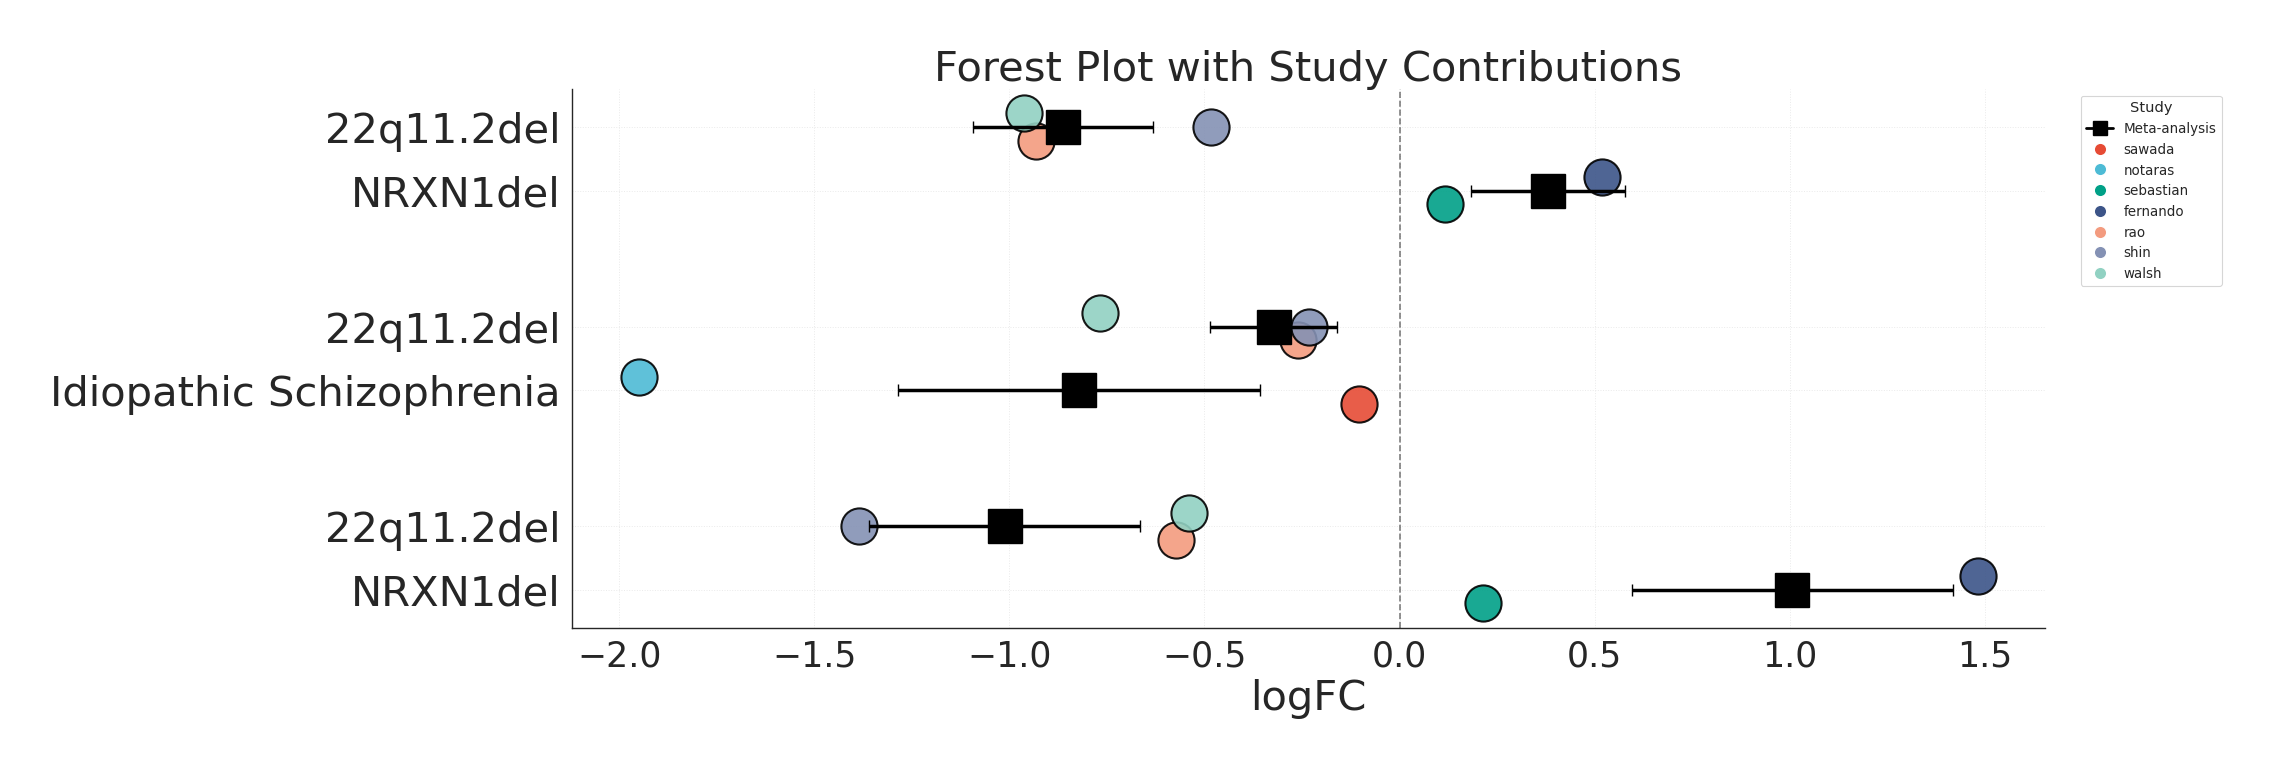

In [83]:

# MANUAL COLORS
META_COLOR = "#000000"

STUDY_COLORS = {
    "logFC_sawada": "#E64B35",
    "logFC_notaras": "#4DBBD5",
    "logFC_sebastian": "#00A087",
    "logFC_fernando": "#3C5488",
    "logFC_rao": "#F39B7F",
    "logFC_shin": "#8491B4",
    "logFC_walsh": "#91D1C2",
}

# =====================================================
# SPACING CONTROL
# =====================================================

WITHIN_GENE_SPACING = 0.7
BETWEEN_GENE_SPACING = 1.5

# =====================================================
# Prepare data
# =====================================================

df = forest_dfs.copy()

logfc_cols = [c for c in df.columns if c.startswith("logFC_")]

df = df.sort_values(["assay", "group"])
df["label"] = df["group"]

# =====================================================
# Custom grouped y positions
# =====================================================

y_positions = []
current_y = 0
prev_gene = None

for _, row in df.iterrows():

    gene = row["assay"]

    if prev_gene is None:
        pass
    elif gene == prev_gene:
        current_y -= WITHIN_GENE_SPACING
    else:
        current_y -= BETWEEN_GENE_SPACING

    y_positions.append(current_y)
    prev_gene = gene

df["y"] = y_positions
df["y"] = df["y"] - df["y"].min()

fig, ax = plt.subplots(figsize=(19, 7))

# GRID CONTROL (EDIT THIS BLOCK)

ax.grid(
    True,
    axis='both',          
    color='#E5E5E5',
    linestyle=':',
    linewidth=0.7,
    alpha=0.8)

# PLOT

for _, row in df.iterrows():

    y = row["y"]

    est = row["estimate"]
    se = row["std.error"]

    ci_low = est - 1.96 * se
    ci_high = est + 1.96 * se

    # meta-analysis
    ax.errorbar(
        est,
        y,
        xerr=[[est - ci_low], [ci_high - est]],
        fmt='s',
        markersize=25,
        color=META_COLOR,
        ecolor=META_COLOR,
        elinewidth=2.5,
        capsize=4,
        markeredgecolor='black',
        zorder=4)

    # individual studies
    study_vals = row[logfc_cols].dropna()
    offsets = np.linspace(-0.15, 0.15, len(study_vals))

    for offset, (col, val) in zip(offsets, study_vals.items()):

        color = STUDY_COLORS.get(col, "#808080")

        ax.scatter(
            val,
            y + offset,
            s=678,
            color=color,
            alpha=0.9,
            edgecolor='black',
            linewidth=1.5,
            zorder=3)

# AXIS FORMATTING

ax.axvline(0, linestyle='--', color='black', alpha=0.5)

ax.set_yticks(df["y"])
ax.set_yticklabels(df["label"])
# # gene labels
# gene_midpoints = df.groupby("assay_ID")["y"].mean()

# for gene, y in gene_midpoints.items():
#     ax.text(
#         ax.get_xlim()[0] - 0.15,
#         y,
#         gene,
#         ha='right',
#         va='center',
#         fontsize=13
#     )

# LEGEND

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=col.replace("logFC_", ""),
        markerfacecolor=color,
        markersize=9)
    for col, color in STUDY_COLORS.items()
]

legend_elements.insert(
    0,
    Line2D([0], [0],
        marker='s',
        color=META_COLOR,
        label='Meta-analysis',
        markersize=10,
        linewidth=2)
)

ax.legend(
    handles=legend_elements,
    title="Study",
    bbox_to_anchor=(1.02, 1),
    loc='upper left')

ax.tick_params(axis='x', labelsize=25)
ax.tick_params(axis='y', labelsize=30)
ax.set_xlabel("logFC", fontsize=30)
ax.set_title("Forest Plot with Study Contributions", fontsize=30)

sns.despine()
# plt.tight_layout()
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_forest_plot.svg", format="svg", bbox_inches="tight", dpi=300)
plt.show()

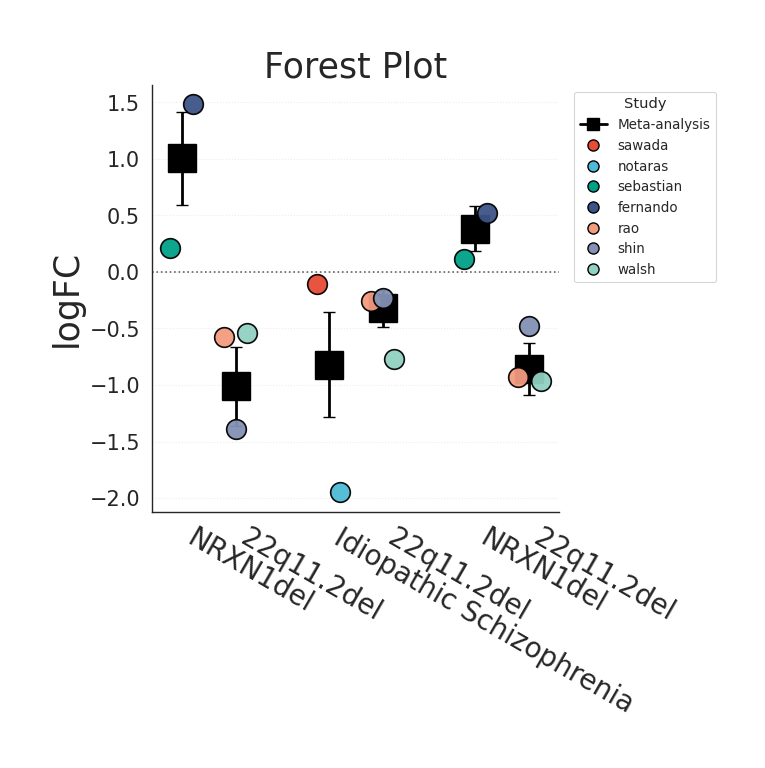

In [86]:
# MANUAL COLORS

META_COLOR = "#000000"

STUDY_COLORS = {
    "logFC_sawada": "#E64B35",
    "logFC_notaras": "#4DBBD5",
    "logFC_sebastian": "#00A087",
    "logFC_fernando": "#3C5488",
    "logFC_rao": "#F39B7F",
    "logFC_shin": "#8491B4",
    "logFC_walsh": "#91D1C2"}

# SPACING CONTROL (NOW ON X-AXIS)

WITHIN_GENE_SPACING = 0.7
BETWEEN_GENE_SPACING = 1.2

# PREPARE DATA

df = forest_dfs.copy()

logfc_cols = [c for c in df.columns if c.startswith("logFC_")]

df = df.sort_values(["assay", "group"])
df["label"] = df["group"]

# CUSTOM X POSITIONS (NOW GROUPED ON X-AXIS)

x_positions = []
current_x = 0
prev_gene = None

for _, row in df.iterrows():

    gene = row["assay"]

    if prev_gene is None:
        pass
    elif gene == prev_gene:
        current_x -= WITHIN_GENE_SPACING
    else:
        current_x -= BETWEEN_GENE_SPACING

    x_positions.append(current_x)
    prev_gene = gene

df["x"] = x_positions
df["x"] = df["x"] - df["x"].min()

# STYLE

sns.set_style("white")
sns.set_context("paper", font_scale=1.1)

fig, ax = plt.subplots(figsize=(7,7))

# GRID

ax.grid(
    True,
    axis='y',
    color='#EAEAEA',
    linestyle=':',
    linewidth=0.8,
    alpha=0.9
)

ax.xaxis.grid(False)
ax.set_axisbelow(True)

# DRAW PLOT (SWAPPED)

for _, row in df.iterrows():

    x = row["x"]

    est = row["estimate"]
    se = row["std.error"]

    ci_low = est - 1.96 * se
    ci_high = est + 1.96 * se

    # -------------------------------------------------
    # META-ANALYSIS (NOW VERTICAL = y-axis)
    # -------------------------------------------------
    ax.errorbar(
        x,
        est,
        yerr=[[est - ci_low], [ci_high - est]],
        fmt='s',
        markersize=20,
        color=META_COLOR,
        ecolor=META_COLOR,
        elinewidth=2.0,
        capsize=4,
        markeredgecolor='black',
        zorder=4
    )

    # STUDY POINTS
    study_vals = row[logfc_cols].dropna()
    offsets = np.linspace(-0.15, 0.15, len(study_vals))

    for offset, (col, val) in zip(offsets, study_vals.items()):

        color = STUDY_COLORS.get(col, "#808080")

        ax.scatter(
            x + offset,
            val,
            s=200,
            color=color,
            alpha=0.95,
            edgecolor='black',
            linewidth=1.2,
            zorder=5
        )

# AXIS FORMATTING

ax.axhline(0, linestyle=':', color='black', alpha=0.6)

ax.set_xticks(df["x"])
ax.set_xticklabels(df["label"])

ax.set_xlabel("Group")
ax.set_ylabel("logFC")

# # GENE LABELS (BOTTOM, NOT TOP)

# gene_midpoints = df.groupby("assay_ID")["x"].mean()

# y_bottom = ax.get_ylim()[0] - 1  # small padding below axis

# for gene, x in gene_midpoints.items():
#     ax.text(
#         x,
#         y_bottom,
#         gene,
#         ha='center',
#         va='top',
#         fontsize=12
#     )

# LEGEND
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=col.replace("logFC_", ""),
        markerfacecolor=color,
        markeredgecolor='black',
        markersize=8
    )
    for col, color in STUDY_COLORS.items()
]

legend_elements.insert(
    0,
    Line2D(
        [0], [0],
        marker='s',
        color=META_COLOR,
        label='Meta-analysis',
        markersize=9,
        linewidth=2
    )
)

ax.legend(
    handles=legend_elements,
    title="Study",
    bbox_to_anchor=(1.02, 1),
    loc='upper left')

plt.setp(
    ax.get_xticklabels(),
    rotation=-30,
    ha='left',
    # rotation_mode='anchor'
)

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=15)
ax.set_xlabel("")
ax.set_ylabel("logFC", fontsize=25)
ax.set_title("Forest Plot", fontsize=25)

# =====================================================
# FINAL CLEANUP
# =====================================================

sns.despine(top=True, right=True)
plt.tight_layout()

plt.savefig(
    "/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_forest_plot_swapped.svg",
    format="svg",
    bbox_inches="tight",
    dpi=300)

plt.show()

In [63]:
wwc_forest_plots = pd.concat([dc_significant_idiopathic_df_logfc[dc_significant_idiopathic_df_logfc['ID'] == 'WWC2'],
                              dc_significant_22q11_df_logfc[dc_significant_22q11_df_logfc['ID'] == 'WWC2'],
                              dc_significant_nrxn1_df_logfc[dc_significant_nrxn1_df_logfc['ID'] == 'WWC2']], axis=0)

In [64]:
wwc_forest_plots

,ID,assay,estimate,std.error,statistic,p.value,n.studies,method,assay_ID,p.adjusted,significant_fdr,logFC_sawada,logFC_notaras,directionally_consistent,mean_logFC,logFC_rao,logFC_shin,logFC_walsh,logFC_sebastian,logFC_fernando
334,WWC2,Radial Glia SOX2+PAX6+FABP7+,0.716472,0.222280,3.223286,1.267291e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | WWC2,0.009917,True,0.441549,0.888741,True,0.665145,NaN,NaN,NaN,NaN,NaN
563,WWC2,Radial Glia SOX2+VIM+FABP7+,0.575885,0.147246,3.911047,9.189683e-05,3,FE,Radial Glia SOX2+VIM+FABP7+ | WWC2,0.005575,True,NaN,NaN,True,0.570024,0.529589,0.604951,0.575531,NaN,NaN
917,WWC2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,-0.977343,0.133706,-7.309649,2.678409e-13,2,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.0,True,NaN,NaN,True,-0.644792,NaN,NaN,NaN,-0.156282,-1.133303


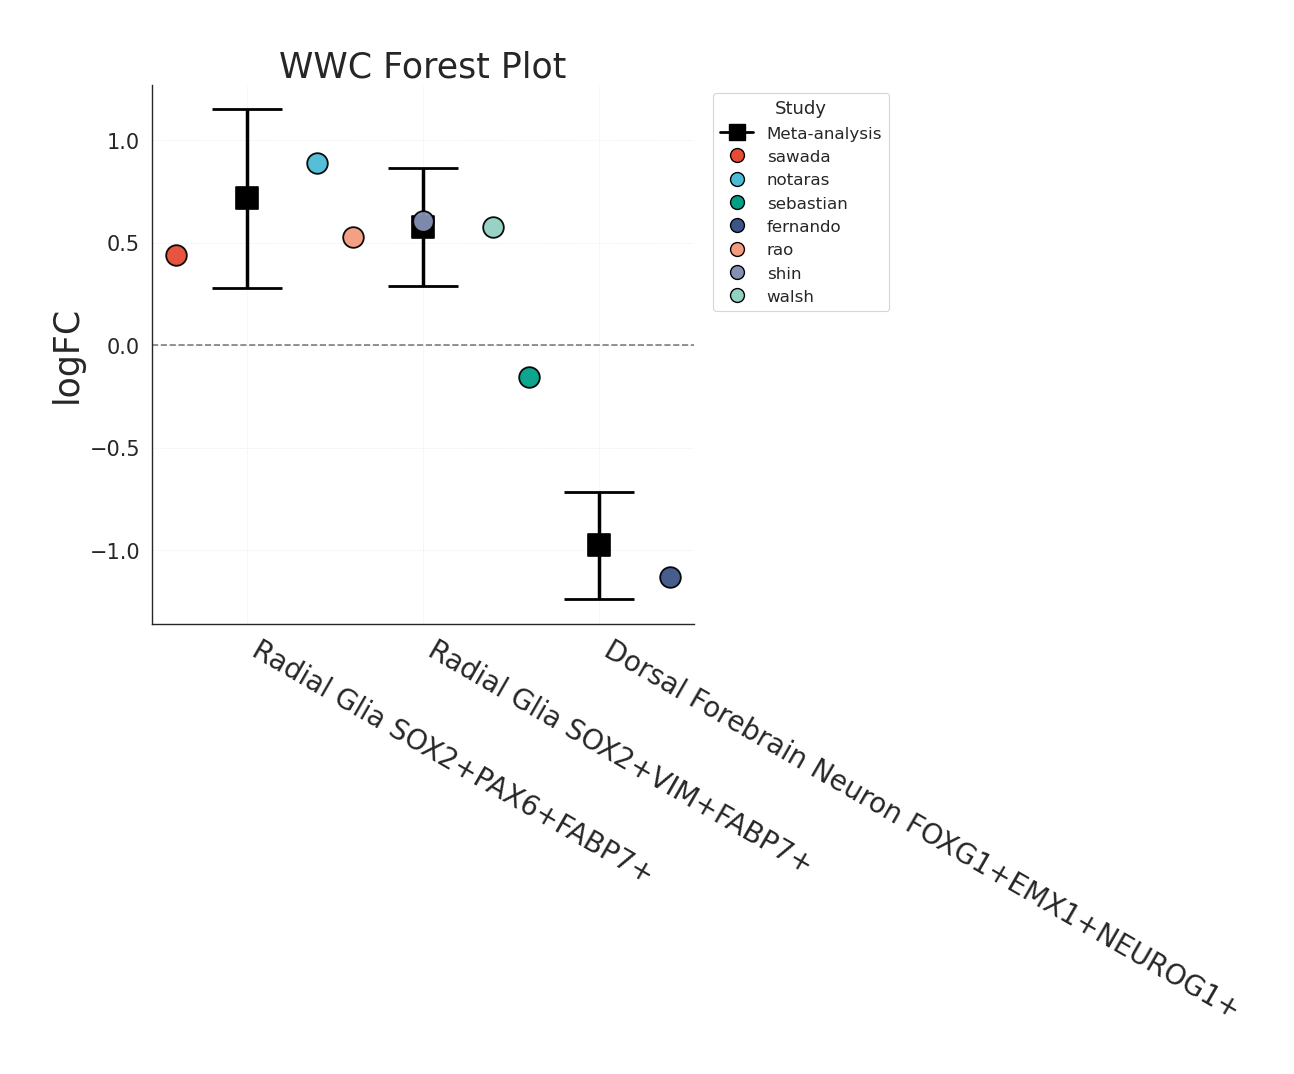

In [88]:
# =====================================================
# FOREST PLOT FOR SINGLE GENE (WWC2)
# Assays = x-axis
# logFC = y-axis
# Meta-analysis estimate = square + CI
# Individual studies = colored circles
# =====================================================

# =====================================================
# MANUAL COLORS
# =====================================================

META_COLOR = "#000000"

STUDY_COLORS = {
    "logFC_sawada": "#E64B35",
    "logFC_notaras": "#4DBBD5",
    "logFC_sebastian": "#00A087",
    "logFC_fernando": "#3C5488",
    "logFC_rao": "#F39B7F",
    "logFC_shin": "#8491B4",
    "logFC_walsh": "#91D1C2",
}

# =====================================================
# SPACING
# =====================================================

COLUMN_SPACING = 0.2

# =====================================================
# PREPARE DATA
# =====================================================

df = wwc_forest_plots.copy()

# all study-level logFC columns
logfc_cols = [c for c in df.columns if c.startswith("logFC_")]

# sort assays
df = df.sort_values("estimate", ascending=False)

# assay labels
df["label"] = df["assay"]

# x positions
df["x"] = np.arange(len(df)) * COLUMN_SPACING

# =====================================================
# FIGURE
# =====================================================

fig, ax = plt.subplots(figsize=(7, 7))

# =====================================================
# GRID
# =====================================================

ax.grid(
    True,
    axis='both',
    color='#E5E5E5',
    linestyle=':',
    linewidth=0.7,
    alpha=0.8
)

# =====================================================
# PLOT
# =====================================================

for _, row in df.iterrows():

    x = row["x"]

    # meta-analysis estimate
    est = row["estimate"]
    se = row["std.error"]

    ci_low = est - 1.96 * se
    ci_high = est + 1.96 * se

    # ---------------------------------------------
    # META-ANALYSIS CI LINE
    # ---------------------------------------------

    ax.vlines(
        x=x,
        ymin=ci_low,
        ymax=ci_high,
        color=META_COLOR,
        linewidth=2.5,
        zorder=1
    )

    # CI caps
    ax.hlines(
        [ci_low, ci_high],
        x - 0.04,
        x + 0.04,
        color=META_COLOR,
        linewidth=2,
        zorder=1
    )

    # ---------------------------------------------
    # META-ANALYSIS SQUARE
    # ---------------------------------------------

    ax.scatter(
        x,
        est,
        marker='s',
        s=260,
        color=META_COLOR,
        edgecolor='black',
        linewidth=1.2,
        zorder=2
    )

    # ---------------------------------------------
    # INDIVIDUAL STUDIES
    # ---------------------------------------------

    study_vals = row[logfc_cols].dropna()

    offsets = np.linspace(-0.08, 0.08, len(study_vals))

    for offset, (col, val) in zip(offsets, study_vals.items()):

        color = STUDY_COLORS.get(col, "#808080")

        ax.scatter(
            x + offset,
            val,
            s=220,
            color=color,
            alpha=0.95,
            edgecolor='black',
            linewidth=1.3,
            zorder=5)

# =====================================================
# AXIS FORMATTING
# =====================================================

# zero line
ax.axhline(
    0,
    linestyle='--',
    color='black',
    alpha=0.5
)

# x labels
ax.set_xticks(df["x"])
ax.set_xticklabels(
    df["label"],
    rotation=25,
    ha='right'
)

# =====================================================
# LEGEND
# =====================================================

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=col.replace("logFC_", ""),
        markerfacecolor=color,
        markeredgecolor='black',
        markersize=10
    )
    for col, color in STUDY_COLORS.items()
]

legend_elements.insert(
    0,
    Line2D(
        [0], [0],
        marker='s',
        color=META_COLOR,
        label='Meta-analysis',
        markersize=11,
        linewidth=2
    )
)

ax.legend(
    handles=legend_elements,
    title="Study",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=12,
    title_fontsize=13
)

# =====================================================
# FINAL FORMATTING
# =====================================================

sns.despine()

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=15)

ax.set_xticks(df["x"])

ax.set_xticklabels(
    df["label"],
    rotation=-30,
    ha='left')

# tick sizes
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=15)
ax.set_ylabel("logFC", fontsize=25)
ax.set_title("WWC Forest Plot", fontsize=25)


plt.savefig(
    "/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_WWC2_forest_plot_vertical.svg",
    format="svg",
    bbox_inches="tight",
    dpi=300)

plt.show()